In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=73d6100805587ad3779108caf7fd5e37f59763f5968cdad01534666f02bc3978
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [43]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_city,
    plot_histogram
)

%matplotlib inline

In [19]:
# Helper Function

def visualize_circuit(qc, title=""):
    """
    Displays:
    1. Circuit Diagram
    2. Statevector
    3. Probability Histogram
    4. State City Plot
    5. Bloch Sphere
    """

    print("="*60)
    print(title)
    print("="*60)

    # Circuit
    display(qc.draw("mpl"))

    # Statevector
    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    # Probabilities
    probs = state.probabilities_dict()

    print("\nMeasurement Probabilities:")
    for k,v in probs.items():
        print(f"|{k}> : {v:.4f}")

    # Histogram
    plot_histogram(probs)
    plt.show()

    # State City
    plot_state_city(state)
    plt.show()

    # Bloch Sphere
    plot_bloch_multivector(state)
    plt.show()

    return state

# Quantum Computing Fundamentals with Qiskit

This notebook demonstrates the fundamental quantum gates and quantum states used in quantum computing.

Topics Covered:

- Hadamard (H) Gate
- Pauli-X Gate
- Pauli-Y Gate
- Pauli-Z Gate
- Phase Gates (S and T)
- CNOT Gate
- Controlled-Z Gate
- Controlled-S Gate
- SWAP Gate
- Bell State
- GHZ State

Each section includes:

- Theory
- Mathematical representation
- Quantum circuit
- Python implementation
- Statevector visualization
- Human-readable explanation

Author: Muhammad Saad

# Hadamard Gate (H)

## Purpose

Creates superposition.

#### Before:

|0⟩

#### After:

(|0⟩ + |1⟩)/√2

#### Human Meaning:

#### Before:
100% chance of 0

#### After:
50% chance of 0
50% chance of 1

This is impossible in classical computing.

Hadamard Gate


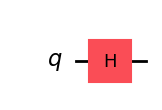


Statevector:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Measurement Probabilities:
|0> : 0.5000
|1> : 0.5000
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [20]:
qc = QuantumCircuit(1)

qc.h(0)

visualize_circuit(
    qc,
    "Hadamard Gate"
)

# Pauli-X Gate

Quantum version of NOT gate.

Before:

|0⟩

After:

|1⟩

Human Meaning:

0 becomes 1.

Pauli-X Gate


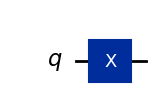


Statevector:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Measurement Probabilities:
|1> : 1.0000
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


In [21]:
qc = QuantumCircuit(1)

qc.x(0)

visualize_circuit(
    qc,
    "Pauli-X Gate"
)

# Pauli-Y Gate

Performs bit flip and phase flip.

Before:

|0⟩

After:

i|1⟩

The i is a phase factor.

Pauli-Y Gate


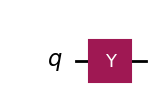


Statevector:
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))

Measurement Probabilities:
|1> : 1.0000
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


In [22]:
qc = QuantumCircuit(1)

qc.y(0)

visualize_circuit(
    qc,
    "Pauli-Y Gate"
)

# Pauli-Z Gate

Changes phase only.

Before:

(|0⟩ + |1⟩)/√2

After:

(|0⟩ - |1⟩)/√2

Human Meaning:

Probability remains same.

Only the phase changes.

Pauli-Z Gate


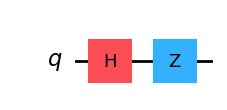


Statevector:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Measurement Probabilities:
|0> : 0.5000
|1> : 0.5000
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [23]:
qc = QuantumCircuit(1)

qc.h(0)
qc.z(0)

visualize_circuit(
    qc,
    "Pauli-Z Gate"
)

# S Gate

90° phase rotation.

Before:

|1⟩

After:

i|1⟩

Changes phase only.

S Gate


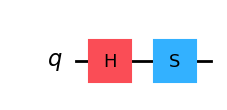


Statevector:
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))

Measurement Probabilities:
|0> : 0.5000
|1> : 0.5000
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


In [24]:
qc = QuantumCircuit(1)

qc.h(0)
qc.s(0)

visualize_circuit(
    qc,
    "S Gate"
)

# T Gate

45° phase rotation.

Before:

|1⟩

After:

e^(iπ/4)|1⟩

Often used in fault-tolerant quantum computing.

T Gate


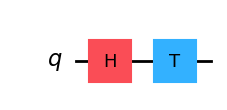


Statevector:
Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))

Measurement Probabilities:
|0> : 0.5000
|1> : 0.5000
Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


In [25]:
qc = QuantumCircuit(1)

qc.h(0)
qc.t(0)

visualize_circuit(
    qc,
    "T Gate"
)

# Controlled-NOT (CNOT)

Control qubit decides whether target flips.

Truth Table

00 → 00
01 → 01
10 → 11
11 → 10

Used to create entanglement.

CNOT Gate


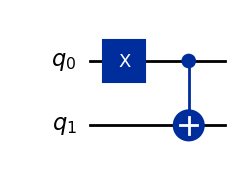


Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))

Measurement Probabilities:
|11> : 1.0000
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


In [26]:
qc = QuantumCircuit(2)

qc.x(0)

qc.cx(0,1)

visualize_circuit(
    qc,
    "CNOT Gate"
)

# Controlled-Z

Adds phase if both qubits are 1.

No classical equivalent exists.

Controlled-Z


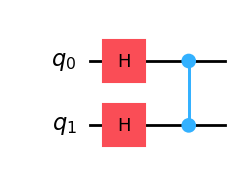


Statevector:
Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))

Measurement Probabilities:
|00> : 0.2500
|01> : 0.2500
|10> : 0.2500
|11> : 0.2500
Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


In [27]:
qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)

qc.cz(0,1)

visualize_circuit(
    qc,
    "Controlled-Z"
)

# Controlled-S

Conditional phase rotation.

Applies S only if control qubit is 1.

Controlled-S


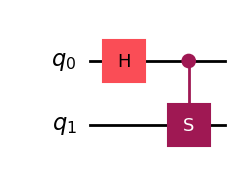


Statevector:
Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))

Measurement Probabilities:
|00> : 0.5000
|01> : 0.5000
Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))


In [28]:
from qiskit.circuit.library import SGate

qc = QuantumCircuit(2)

qc.h(0)

qc.append(
    SGate().control(1),
    [0,1]
)

visualize_circuit(
    qc,
    "Controlled-S"
)

# SWAP Gate

Exchanges the values of two qubits.

Before:

|01⟩

After:

|10⟩

SWAP Gate


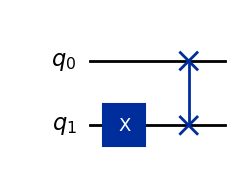


Statevector:
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

Measurement Probabilities:
|01> : 1.0000
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [29]:
qc = QuantumCircuit(2)

qc.x(1)

qc.swap(0,1)

visualize_circuit(
    qc,
    "SWAP Gate"
)

# Bell State

First Entangled State

(|00⟩ + |11⟩)/√2

Applications:

- Quantum Teleportation
- Superdense Coding
- Quantum Key Distribution

Measurement Correlation:

If first qubit becomes 0,
second MUST become 0.

If first qubit becomes 1,
second MUST become 1.

Bell State


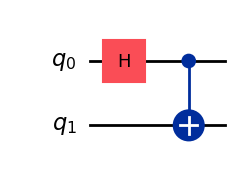


Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Measurement Probabilities:
|00> : 0.5000
|11> : 0.5000
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [30]:
qc = QuantumCircuit(2)

qc.h(0)

qc.cx(0,1)

visualize_circuit(
    qc,
    "Bell State"
)

Measurement Counts:
{'00': 495, '11': 505}


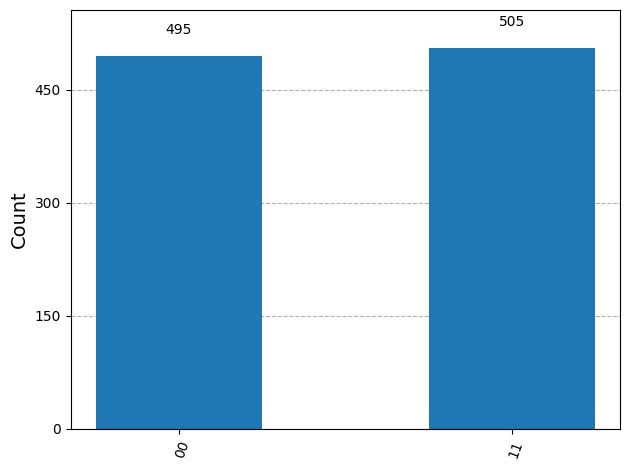

In [44]:
qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

qc.measure([0, 1], [0, 1])

sim = AerSimulator()

result = sim.run(qc, shots=1000).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

display(plot_histogram(counts))

# GHZ State

Three-Qubit Bell State

(|000⟩ + |111⟩)/√2

Demonstrates multi-qubit entanglement.

If one qubit is measured as 0,
all become 0.

If one qubit is measured as 1,
all become 1.

GHZ State


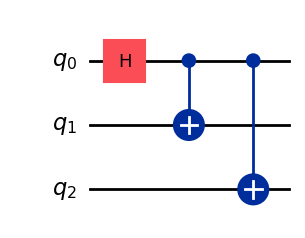


Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))

Measurement Probabilities:
|000> : 0.5000
|111> : 0.5000
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


In [32]:
qc = QuantumCircuit(3)

qc.h(0)

qc.cx(0,1)
qc.cx(0,2)

visualize_circuit(
    qc,
    "GHZ State"
)

Measurement Counts:
{'000': 512, '111': 488}


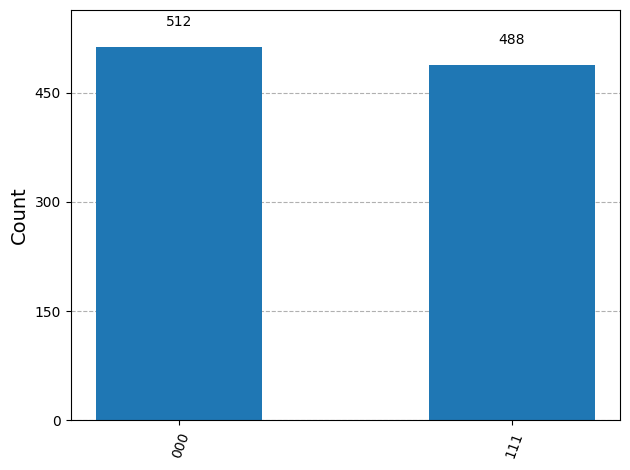

In [45]:
qc = QuantumCircuit(3, 3)

qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.measure([0, 1, 2], [0, 1, 2])

sim = AerSimulator()

result = sim.run(qc, shots=1000).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

display(plot_histogram(counts))